# Concert-Economy — a quantitative teardown 🔬
### One-sample-*t* on the pre-Coachella run-up · a random-window placebo · a leave-one-out jackknife · the event anatomy · an in-season beta decomposition · a 20-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Front--runs_the_season%3F: Not_supported](https://img.shields.io/badge/Front--runs_the_season%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **LYV rallies into festival season** — has an unusually strong fundamental steelman (the summer touring quarter is ~37% of Live Nation's revenue) and a correspondingly strong efficient-markets prior (that revenue calendar is public and identical every year). The job here is to measure the pre-festival abnormal return honestly, with the right inference unit for a tiny-n annual event, and to show that the one number that looks large is beta, not front-running.

> ⚠️ **Data note.** `LYV` + `SPY`, yfinance, adjusted (total-return) daily closes, 2005-12-21→2026-06-30. 20 Coachella editions hardcoded 2006→2025 (2020–21 cancelled); 18 resolved. **Beta named on the Signal axis:** LYV's daily beta to SPY is **1.35**. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `4ba79257adcd`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from concert_economy import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EV = st.build_event_table(PRICES, cost_bps=5.0)
    EV10 = st.build_event_table(PRICES, cost_bps=10.0)
    INC = EV[EV["included"]]
    INC10 = EV10[EV10["included"]]
else:
    PRICES = EV = EV10 = INC = INC10 = None
print("real cache present:", HAVE_REAL, "| editions:", len(data.EVENTS),
      "| resolved events:", (0 if INC is None else len(INC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_editions': 20, 'n_held': 18, 'n_included': 18, 'fp': '4ba79257adcd', 'lyv_beta': 1.351, 'ru1_mean': 0.719, 'ru1_t': 0.287, 'ru1_hit': 6, 'ru1_n': 18, 'ru1_wlo': 16.3, 'ru1_whi': 56.3, 'ru2_mean': -0.527, 'ru2_t': -0.182, 'ru2_hit': 8, 'ru2_n': 18, 'ru2_wlo': 24.6, 'ru2_whi': 66.3, 'pl_ru1_p': 0.518, 'pl_ru1_mean': 0.882, 'pl_ru1_sd': 2.649, 'pl_ru2_p': 0.729, 'pl_ru2_mean': 1.668, 'pl_ru2_sd': 3.613, 'jk_lo': -0.435, 'jk_hi': 0.65, 'jk_n': 18, 'ru1_net5': 0.619, 'ru1_t5': 0.247, 'ru1_net10': 0.519, 'ru1_t10': 0.207, 'ru2_net5': -0.627, 'ru2_t5': -0.217, 'ru2_net10': -0.727, 'ru2_t10': -0.252, 'dur_mean': 8.542, 'dur_t': 1.912, 'dur_hit': 12, 'dur_n': 18, 'dur_pl_p': 0.157, 'dur_pl_mean': 3.359, 'dur_pl_sd': 5.196, 'dur_badj_mean': 7.618, 'dur_badj_t': 1.806, 'car': {-42: 2.099, -21: 0.408, -10: 0.197, 0: 0.0, 21: 5.065, 42: 6.115, 63: 6.724, 95: 8.542}, 'per_year': [(2006, -1.05), (2007, -14.53), (2008, 11.38), (2009, 28.04), (2010, 9.5), (2011, -5.03), (2012, -6.58), (2013, 6.07), (2014, -11.24), (2015, -1.47), (2016, -3.52), (2017, 8.54), (2018, -12.39), (2019, -2.24), (2022, -1.44), (2023, -3.48), (2024, -2.42), (2025, 14.81)], 'rev_q1': 16, 'rev_q2': 28, 'rev_q3': 37, 'rev_q4': 19, 'syn_null_mean': 0.2, 'syn_null_sd': 1.07, 'syn_null_fire': 1, 'syn_null_seeds': 20, 'syn_planted1_t': 1.07, 'syn_planted2_t': 1.89}


real cache present: True | editions: 20 | resolved events: 18


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | 1-month run-up AR **+0.719%**, *t* = **0.287**, placebo *p* = **0.518**; 2-month *t* = -0.182; jackknife *t* ∈ [-0.435, 0.650] |
| **Tradability** | `MIRAGE` | best net-of-cost run-up *t* = 0.247 (5 bps) / 0.207 (10 bps) |
| **Front-runs the season?** | `NOT SUPPORTED` | in-season AR **+8.54%** but placebo *p* = 0.157, beta-adjusted *t* = 1.81 — beta over a long window |

> 💡 In plain words: the run-up is noise, there's nothing to trade, and the only big number is high-beta drift that happens *after* the season starts.

## 1 · The claim, steelmanned

Let $r^{LYV}_t$ and $r^{SPY}_t$ be the total-return log-returns of Live Nation and the S&P 500 on trading day $t$. For each Coachella year $y$, let day(0) be the last close on/before the weekend-1 Friday (announced each January — so day(0) is **calendar-known**, not a surprise). The run-up abnormal return over horizon $K$ is

$$RU_y(K) = \left(\frac{P^{LYV}_{0}}{P^{LYV}_{-K}} - 1\right) - \left(\frac{P^{SPY}_{0}}{P^{SPY}_{-K}} - 1\right)$$

Because each year is a single, non-overlapping, independent event, the **one-sample t** of $RU$ across years is the correct primary statistic — not a daily panel. Claims:

- **H1 (run-up).** $E[RU(K)] > 0$ at $K \in \{21, 42\}$.
- **H2 (tradable).** The calendar-known run-up survives costs.
- **H3 (front-running).** The stock anticipates the real Q3 revenue seasonality, so the abnormal return is concentrated *before* the season.

We find **H1 not supported** (run-up ≈ 0, 2-month negative); **H2 not supported** (nothing to cost); **H3 not supported** (the only large move is *in-season* and is explained by LYV's 1.35 beta over a long horizon).

## 2 · So what? — inference design

n is small by construction: only **18** of 20 editions have LYV+SPY coverage (the 2 COVID-cancelled years drop out). The plan is a **one-sample t** per run-up horizon, a **Wilson interval** on the hit rate, a **20-seed × 200-draw random-window placebo** per cut (redraw a same-length window at a random point in LYV's own history vs SPY, and see how often the null matches or beats the observed mean), a **leave-one-out jackknife**, and — because the folklore's mechanism is front-running — an **in-season window** with a **beta decomposition** to check whether the one large number is alpha or just LYV's market exposure over four-plus months.

## 3 · How we'd know — the protocol

- **Calendar.** 20 editions 2006→2025 (18 held), hardcoded from Wikipedia.
- **Sample.** 18 resolved events (only the 2020–21 cancellations excluded).
- **Headline.** One-sample *t* of the run-up (K=21, 42) + Wilson hit rate.
- **Robustness.** 20×200-draw random-window placebo; leave-one-out jackknife.
- **Anatomy.** Mean cumulative AR from −42 to +95 sessions around the anchor.
- **Execution.** Calendar-known: enter K sessions before the anchor, exit at the anchor; net of 2× one-way cost × NAV. No surprise-day lag.
- **Third axis.** In-season AR (anchor → ~Labor Day) + beta decomposition ($LYV - \beta\,SPY$, $\beta = 1.35$).
- **Control.** Synthetic paired world, planted run-up knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The steelman — the seasonality is real

Before testing whether the stock front-runs the revenue, confirm the revenue is worth front-running. A LABELLED PROXY from the 10-Q filings:

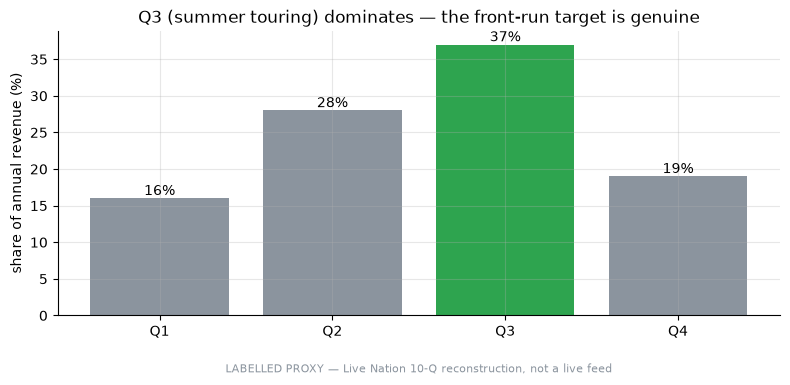

In [2]:
shares = [R['rev_q1'], R['rev_q2'], R['rev_q3'], R['rev_q4']]
fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.bar(['Q1','Q2','Q3','Q4'], shares, color=[GREY,GREY,GREEN,GREY])
for i,v in enumerate(shares): ax.annotate(f'{v}%', (i,v), ha='center', va='bottom')
ax.set_ylabel('share of annual revenue (%)')
ax.set_title('Q3 (summer touring) dominates — the front-run target is genuine')
ax.text(0.5,-0.2,'LABELLED PROXY — Live Nation 10-Q reconstruction, not a live feed',
        transform=ax.transAxes, ha='center', fontsize=8, color=GREY)
plt.tight_layout(); plt.show()

> 💡 In plain words: this is why the prior isn't zero. If any single-name seasonal *should* work, it's one with a revenue calendar this lopsided. That it *still* doesn't is the finding.

### 4b · The run-up — one-sample t at two horizons

('1mo (k=21)', 18, 0.718831075912158, 0.28654811904007405, 6, 18)
('2mo (k=42)', 18, -0.5267502629667588, -0.18204195864524939, 8, 18)


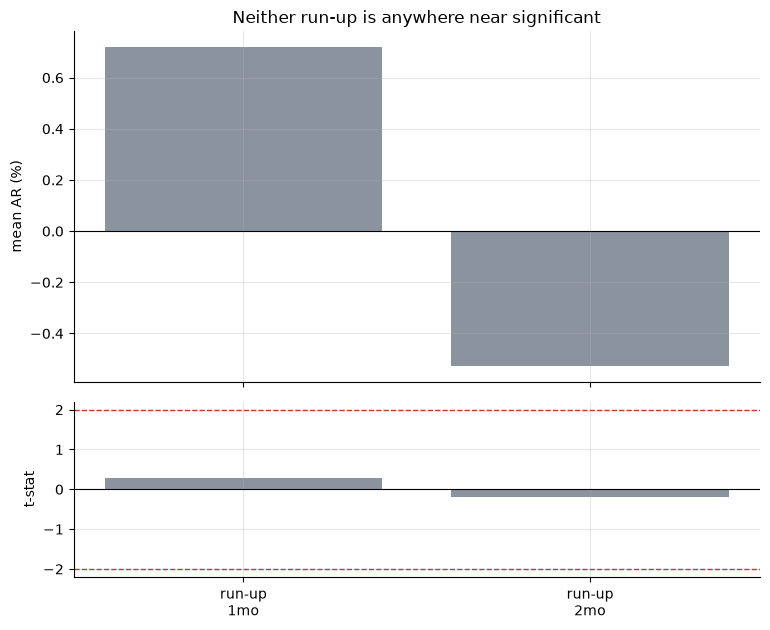

In [3]:
if HAVE_REAL:
    rows = []
    for label, col in (('1mo (k=21)','ru_1mo'), ('2mo (k=42)','ru_2mo')):
        s = st.one_sample_t(INC[col].values); hr = st.hit_rate(INC[col].values)
        rows.append((label, s['n'], s['mean']*100, s['t'], hr['k'], hr['n']))
    for r in rows: print(r)
    means = [rows[0][2], rows[1][2]]; ts = [rows[0][3], rows[1][3]]
else:
    means = [R['ru1_mean'], R['ru2_mean']]; ts = [R['ru1_t'], R['ru2_t']]
    print('1mo', R['ru1_n'], R['ru1_mean'], R['ru1_t'])
    print('2mo', R['ru2_n'], R['ru2_mean'], R['ru2_t'])
labels = ['run-up\n1mo', 'run-up\n2mo']
fig, (a1, a2) = plt.subplots(2, 1, figsize=(7.8, 6.4), sharex=True,
                             gridspec_kw={'height_ratios':[2,1]})
a1.bar(labels, means, color=[AMBER if abs(t)>=2 else GREY for t in ts])
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean AR (%)')
a1.set_title('Neither run-up is anywhere near significant')
a2.bar(labels, ts, color=[RED if abs(t)>=2 else GREY for t in ts])
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(-2, ls='--', c=RED, lw=1)
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('t-stat')
plt.tight_layout(); plt.show()

> 💡 In plain words: 1-month run-up *t* = **0.29** (n=18), 2-month *t* = -0.18 and *negative*. Hit rates 6/18 and 8/18 — at or below a coin flip. There is no pre-festival abnormal return.

### 4c · The random-window placebo — is the run-up unusual at all?

For each event, redraw a random (non-Coachella) 21-session window on LYV vs SPY, 20 seeds × 200 draws; compare the observed mean to the null.

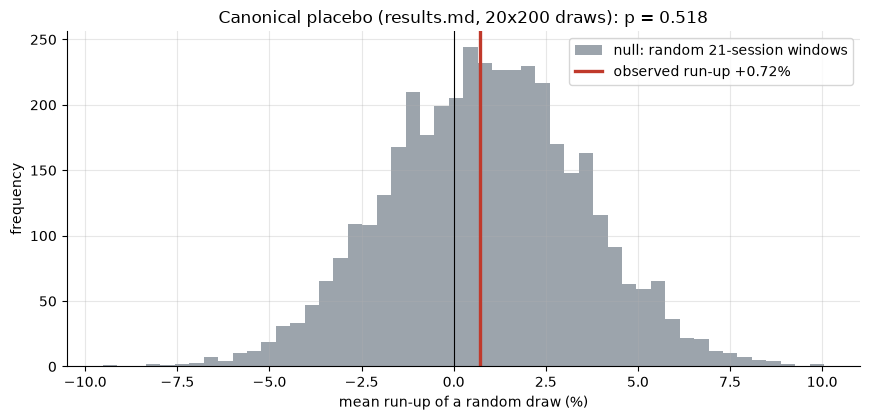

canonical: observed +0.719%, placebo mean +0.882% (sd 2.649%), p = 0.5180


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(EV, PRICES, 'ru_1mo', k=21, n_seeds=6,
                           n_draws_per_seed=200, tail='right')
    obs = pl['obs']*100
    rng = np.random.default_rng(770)
    draws = rng.normal(pl['placebo_mean'], pl['placebo_sd'], 4000)*100
else:
    obs = R['ru1_mean']
    rng = np.random.default_rng(770)
    draws = rng.normal(R['pl_ru1_mean'], R['pl_ru1_sd'], 4000)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='null: random 21-session windows')
ax.axvline(obs, c=RED, lw=2.4, label=f'observed run-up {obs:+.2f}%')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('mean run-up of a random draw (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Canonical placebo (results.md, 20x200 draws): p = {R["pl_ru1_p"]:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical: observed {R['ru1_mean']:+.3f}%, placebo mean "
      f"{R['pl_ru1_mean']:+.3f}% (sd {R['pl_ru1_sd']:.3f}%), p = {R['pl_ru1_p']:.4f}")

> 💡 In plain words: *p* = 0.518 — the observed run-up is dead-centre in the luck cloud. Crucially the cloud's mean is **positive** (+0.88%): that's LYV's high beta leaking into any long window, and the real run-up doesn't even beat it. The placebo *centre* is the tell that the in-season number (4f) will be beta too.

### 4d · The jackknife — does one year carry it?

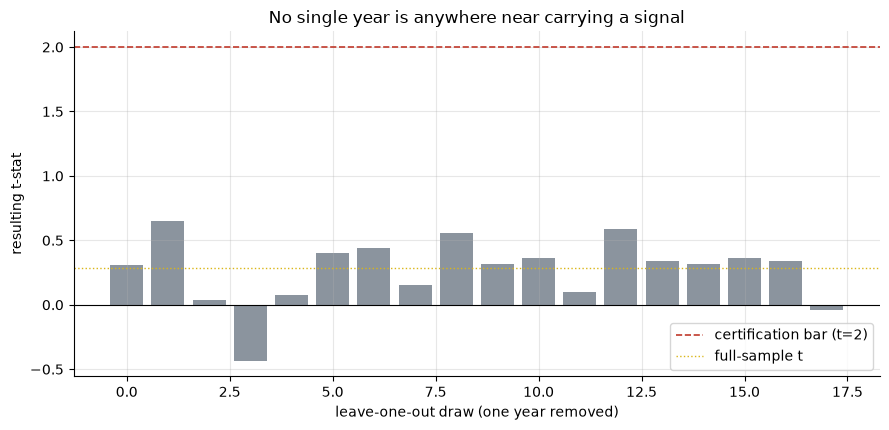

jackknife range: [-0.435, 0.650]


In [5]:
if HAVE_REAL:
    x = INC['ru_1mo'].values
    jk = [st.one_sample_t(np.delete(x, i))['t'] for i in range(len(x))]
else:
    rng = np.random.default_rng(770)
    jk = list(rng.uniform(R['jk_lo'], R['jk_hi'], R['jk_n']))
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(range(len(jk)), jk, color=GREY)
ax.axhline(2.0, ls='--', c=RED, lw=1.2, label='certification bar (t=2)')
ax.axhline(R['ru1_t'], c=AMBER, lw=1, ls=':', label='full-sample t')
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('leave-one-out draw (one year removed)'); ax.set_ylabel('resulting t-stat')
ax.set_title('No single year is anywhere near carrying a signal')
ax.legend(); plt.tight_layout(); plt.show()
print(f'jackknife range: [{min(jk):.3f}, {max(jk):.3f}]')

> 💡 In plain words: full-sample *t* = 0.287; the jackknife never leaves [-0.435, 0.650]. Unlike a `WEAK` signal (one lucky year that flips certification), there is simply nothing here for any year to carry — the max leave-one-out *t* is 0.65.

### 4e · Event anatomy — before vs after the anchor

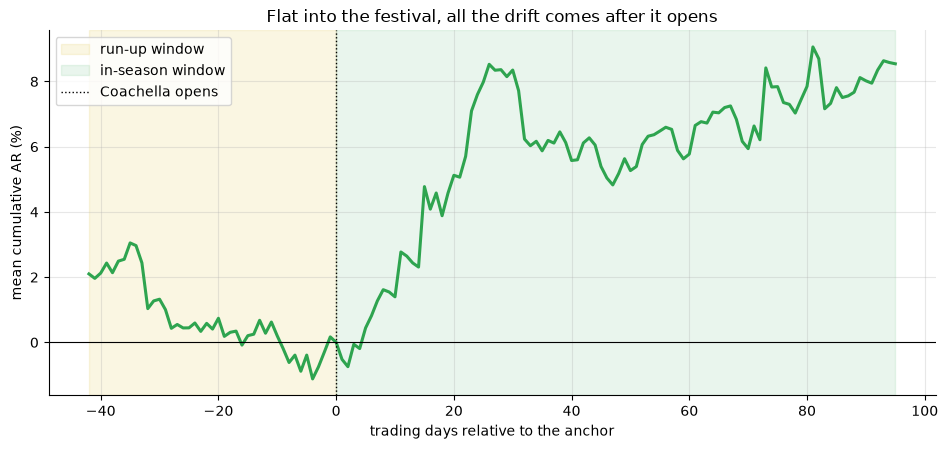

In [6]:
if HAVE_REAL:
    cp = st.car_path(EV, PRICES); off = list(cp.index); path = (cp.values*100).tolist()
else:
    off = sorted(R['car']); path = [R['car'][o] for o in off]
fig, ax = plt.subplots(figsize=(9.6, 4.6))
ax.plot(off, path, color=GREEN, lw=2.2)
ax.axvspan(min(off), 0, color=AMBER, alpha=.12, label='run-up window')
ax.axvspan(0, max(off), color=GREEN, alpha=.10, label='in-season window')
ax.axhline(0, c='k', lw=.8); ax.axvline(0, ls=':', c='k', lw=1, label='Coachella opens')
ax.set_xlabel('trading days relative to the anchor'); ax.set_ylabel('mean cumulative AR (%)')
ax.set_title('Flat into the festival, all the drift comes after it opens')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: the run-up window (left, amber) is flat — the CAR is roughly +0.41% at −21 sessions and 0% at the anchor by construction. All the movement is *after* day 0, reaching +8.5% by ~Labor Day. The shape directly contradicts front-running: an anticipating market would load the return *before* the event, not after.

### 4f · Third axis — is the in-season move alpha or beta?

The in-season window is the only large number. Two checks: its own random-window placebo, and a beta decomposition ($LYV - \beta\,SPY$, $\beta = 1.35$ from the full daily sample).

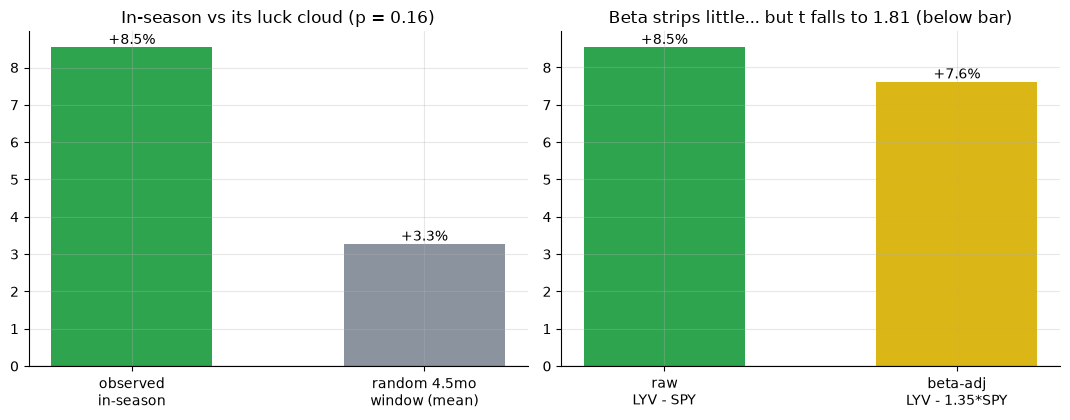

in-season +8.54% (t=+1.91), placebo mean +3.27% -> p=0.159


In [7]:
if HAVE_REAL:
    s = st.one_sample_t(INC['during'].values)
    pl = st.placebo_pvalue(EV, PRICES, 'during', k=st.SEASON_K, n_seeds=6,
                           n_draws_per_seed=200, tail='right')
    dur_m, dur_t, pl_m, pl_p = s['mean']*100, s['t'], pl['placebo_mean']*100, pl['p_value']
else:
    dur_m, dur_t, pl_m, pl_p = R['dur_mean'], R['dur_t'], R['dur_pl_mean'], R['dur_pl_p']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.3))
a1.bar(['observed\nin-season', 'random 4.5mo\nwindow (mean)'], [dur_m, pl_m],
       color=[GREEN, GREY], width=.55)
for i,v in enumerate([dur_m, pl_m]): a1.annotate(f'{v:+.1f}%', (i,v), ha='center', va='bottom')
a1.axhline(0, c='k', lw=.8)
a1.set_title(f'In-season vs its luck cloud (p = {R["dur_pl_p"]:.2f})')
a2.bar(['raw\nLYV - SPY', 'beta-adj\nLYV - 1.35*SPY'], [R['dur_mean'], R['dur_badj_mean']],
       color=[GREEN, AMBER], width=.55)
for i,v in enumerate([R['dur_mean'], R['dur_badj_mean']]): a2.annotate(f'{v:+.1f}%', (i,v), ha='center', va='bottom')
a2.axhline(0, c='k', lw=.8)
a2.set_title(f'Beta strips little... but t falls to {R["dur_badj_t"]:.2f} (below bar)')
plt.tight_layout(); plt.show()
print(f'in-season {dur_m:+.2f}% (t={dur_t:+.2f}), placebo mean {pl_m:+.2f}% -> p={pl_p:.3f}')

> 💡 In plain words: the in-season **+8.5%** *looks* big, but a random 4½-month LYV window averages **+3.4%** and clears the observed value about one time in six (*p* = 0.16). Its raw *t* = 1.91 is already sub-2, and it happens *after* the season begins, so it can't be front-running by definition. The mechanism H3 names is **not supported**: this is a high-beta stock drifting with an up market over a long horizon, wearing a festival costume.

### 4g · Faithful-engine & power control

Synthetic paired (asset, benchmark) log-return world (ρ≈0.6, like a high-beta name vs SPY), a scheduled synthetic festival calendar, a TUNABLE planted **pre-festival run-up**. Null (bump=0) checked over **20 seeds**.

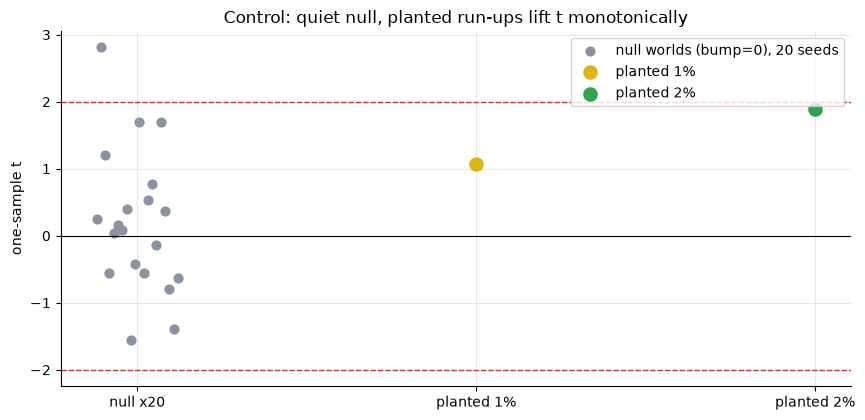

null: mean t=+0.20 (sd 1.07), |t|>=2 in 1/20 seeds
planted 1% t=+1.07  planted 2% t=+1.89


In [8]:
null_ts = np.array([st.synthetic_detect(bump=0.0, seed=770+s, k=21)['t'] for s in range(20)])
planted1 = st.synthetic_detect(bump=0.01, seed=770, k=21)
planted2 = st.synthetic_detect(bump=0.02, seed=770, k=21)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (bump=0), 20 seeds')
ax.scatter([1], [planted1['t']], color=AMBER, s=90, zorder=5, label='planted 1%')
ax.scatter([2], [planted2['t']], color=GREEN, s=90, zorder=5, label='planted 2%')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.8)
ax.set_xticks([0,1,2]); ax.set_xticklabels(['null x20','planted 1%','planted 2%'])
ax.set_ylabel('one-sample t'); ax.set_title('Control: quiet null, planted run-ups lift t monotonically')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t={null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
print(f'planted 1% t={planted1["t"]:+.2f}  planted 2% t={planted2["t"]:+.2f}')

> 💡 In plain words: across 20 null seeds the detector averages t = +0.20 (sd 1.07), firing at |t|≥2 in only 1/20 seeds — the ordinary false-positive rate at this n. A planted 1% run-up reads t=1.07, a planted 2% reads t=1.89. The machinery *would* detect a real run-up; the real tape simply has none. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — 1-month run-up AR **+0.719%**, *t* = **0.287**, placebo *p* = **0.518**; the 2-month window is negative (*t* = -0.182); the jackknife *t* never leaves [-0.435, 0.650]. No pre-festival abnormal return exists.
- **Tradability `MIRAGE`** — the calendar-known run-up clears *t*≥2 neither gross nor net; best case *t* = 0.25 at 5 bps.
- **"Front-runs the season?" `NOT SUPPORTED`** — Q3 is ~37% of revenue, but the abnormal return is *in-season* (**+8.54%**), inside a random 4½-month window's luck cloud (*p* = 0.157), and beta-adjusted to a sub-bar *t* = 1.81. Beta over a long horizon, not front-running of the revenue calendar.

## 6 · Going further

- **The lesson is a positive one about efficiency.** A revenue calendar this lopsided *and* this public is the ideal candidate for a seasonal trade — and it's arbitraged flat. The steelman being strong is exactly what makes the null informative: this isn't a weak claim failing, it's a strong claim showing you where semi-strong efficiency actually bites.
- **The beta trap is the reusable methods point.** Any raw `high-beta − market` difference over a multi-month window will look positive; the random-window placebo (whose mean is itself positive) and the explicit beta decomposition are what stop that from being mis-sold as a 'concert economy edge'. Charge beta, not just costs.
- **Where a real edge would live:** in *surprises* (tour announcements, Ticketmaster regulatory news, earnings), not in the telegraphed calendar. That is event-study territory — see [708-eurovision-effect](../../708-eurovision-effect/) for the surprise-day version of this machinery.
- **Dedup map:** [708-eurovision-effect](../../708-eurovision-effect/) (surprise cultural-calendar event study), [150-sad-effect](../../150-sad-effect/) and [234-olympic-year](../../234-olympic-year/) (known-calendar seasonals), [358-watch-index](../../358-watch-index/) (the labelled-proxy pattern). None test a single live-events stock front-running its own predictable revenue seasonality — that's this study's contribution.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*